# Análisis de escenarios

**Curso** CC2017 Modelación y Simulación · Universidad del Valle de Guatemala
**Proyecto** Simulación estocástica del forrajeo y la polinización de abejas

---

### Alcance

Analiza la campaña experimental completa: los doce escenarios de la matriz, con
500 réplicas cada uno y un conjunto de semillas compartido, de modo que todos se
comparan sobre la misma suerte.

De este documento salen las tablas de la sección de Resultados del informe.

### Origen de los datos

Cada réplica dejó en disco su CSV de viajes, su configuración exacta y su
resumen. Aquí se leen los 6,000 resúmenes; nada se transcribió a mano y ninguna
figura se construyó con números escritos por fuera.

### Advertencia de lectura

Los escenarios se comparan sobre **distribuciones de réplicas**, no sobre
corridas individuales. Un escenario que fija la disponibilidad floral consume
los números aleatorios en distinto orden que uno que la sortea, así que las
réplicas con la misma semilla no son comparables viaje por viaje aunque sí lo
sean en agregado.

In [1]:
import json, math, glob, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, '../src')
from bee_sim.analysis.campaign_io import cargar_resumenes

AMBAR, SALVIA, TINTA, ALERTA = '#B87813', '#4F6B4A', '#43463C', '#A2402A'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

RAIZ = '../results/runs'
ORDEN = ['bees_low','base','bees_high','flowers_low','flowers_high',
         'distance_near','distance_far','lambda_low','lambda_high',
         'pollination_low','pollination_high','combined']
ETIQUETA = {'base':'BASE','bees_low':'ABEJAS-BAJA','bees_high':'ABEJAS-ALTA',
            'flowers_low':'FLORES-BAJA','flowers_high':'FLORES-ALTA',
            'distance_near':'DIST-CERCA','distance_far':'DIST-LEJOS',
            'lambda_low':'LAMBDA-BAJA','lambda_high':'LAMBDA-ALTA',
            'pollination_low':'POLIN-BAJA','pollination_high':'POLIN-ALTA',
            'combined':'COMBINADO'}

filas = cargar_resumenes(RAIZ, ultimos_por_escenario=500)
df = pd.DataFrame(filas)
print(f'{len(df):,} réplicas leídas de {df.escenario.nunique()} escenarios')
print(df.groupby('escenario').size().reindex(ORDEN).to_string())

6,000 réplicas leídas de 12 escenarios
escenario
bees_low            500
base                500
bees_high           500
flowers_low         500
flowers_high        500
distance_near       500
distance_far        500
lambda_low          500
lambda_high         500
pollination_low     500
pollination_high    500
combined            500


## 1. Comparación global de escenarios

La tabla que el informe reserva en la sección de Resultados. Cada celda es la
media sobre las 500 réplicas del escenario.

In [2]:
COLS = ['salidas_totales','salidas_perdidas','viajes_completos','flores_visitadas',
        'flores_polinizadas','flores_polinizadas_viajes_que_caben',
        'flores_polinizadas_viajes_completos','nectar_entregado_ml',
        'tasa_retorno','duracion_media_min']
faltantes = [c for c in COLS if c not in df.columns]
if faltantes:
    raise ValueError('Faltan métricas actualizadas en los resúmenes: ' + ', '.join(faltantes) +
                     '. Ejecuta update_campaign_metadata.py al terminar la campaña.')
tabla = df.groupby('escenario')[COLS].mean().reindex(ORDEN)
tabla.index = [ETIQUETA[e] for e in tabla.index]
tabla.columns = ['Salidas','Perdidas','Viajes compl.','Visitadas',
                 'Polin. planif.','Polin. en jornada','Polin. retornos',
                 'Néctar (ml)','Retorno %','Duración (min)']
tabla['Retorno %'] = tabla['Retorno %'] * 100
pd.set_option('display.width', 140)
print(tabla.to_string(formatters={
    'Salidas':       lambda v: f'{v:9,.1f}',
    'Perdidas':      lambda v: f'{v:9,.1f}',
    'Viajes compl.': lambda v: f'{v:9,.1f}',
    'Visitadas':     lambda v: f'{v:10,.1f}',
    'Polin. planif.':lambda v: f'{v:13,.1f}',
    'Polin. en jornada':lambda v: f'{v:16,.1f}',
    'Polin. retornos':lambda v: f'{v:15,.1f}',
    'Néctar (ml)':   lambda v: f'{v:11,.1f}',
    'Retorno %':     lambda v: f'{v:9,.2f}',
    'Duración (min)':lambda v: f'{v:14,.2f}'}))

              Salidas  Perdidas Viajes compl.  Visitadas Polin. planif. Polin. en jornada Polin. retornos Néctar (ml) Retorno % Duración (min)
ABEJAS-BAJA   1,201.2     196.8         976.9    8,037.6        5,222.8           5,102.0         5,078.7       496.3     97.26          14.58
BASE          1,201.2       0.0       1,166.5    9,610.9        6,244.5           6,089.8         6,061.5       592.4     97.11          14.58
ABEJAS-ALTA   1,201.2       0.0       1,166.5    9,610.9        6,244.5           6,089.8         6,061.5       592.4     97.11          14.58
FLORES-BAJA   1,201.2       0.0       1,164.2    4,802.2        3,120.7           3,036.3         3,022.2       167.5     96.92          15.71
FLORES-ALTA   1,201.2       0.0       1,166.0   16,822.2       10,933.2          10,658.5        10,607.7     1,322.4     97.07          14.71
DIST-CERCA    1,201.2       0.0       1,179.3    9,610.9        6,244.5           6,129.2         6,128.5       599.0     98.18          10.82

In [3]:
# Desviacion estandar entre replicas: cuanta de la variacion es suerte
sd = df.groupby('escenario')[['flores_polinizadas','tasa_retorno']].std().reindex(ORDEN)
mu = df.groupby('escenario')[['flores_polinizadas','tasa_retorno']].mean().reindex(ORDEN)
cv = (sd / mu * 100)
res = pd.DataFrame({
    'Polinizadas (media)': mu.flores_polinizadas,
    'Polinizadas (sd)': sd.flores_polinizadas,
    'CV %': cv.flores_polinizadas,
    'Retorno (media)': mu.tasa_retorno,
    'Retorno (sd)': sd.tasa_retorno,
    'CV % ': cv.tasa_retorno})
res.index = [ETIQUETA[e] for e in res.index]
print(res.to_string(float_format=lambda v: f'{v:,.3f}'))

             Polinizadas (media)  Polinizadas (sd)  CV %  Retorno (media)  Retorno (sd)  CV % 
ABEJAS-BAJA            5,222.798           214.114 4.100            0.973         0.003  0.284
BASE                   6,244.536           205.245 3.287            0.971         0.005  0.518
ABEJAS-ALTA            6,244.536           205.245 3.287            0.971         0.005  0.518
FLORES-BAJA            3,120.738           107.635 3.449            0.969         0.005  0.505
FLORES-ALTA           10,933.244           330.404 3.022            0.971         0.005  0.505
DIST-CERCA             6,244.536           205.245 3.287            0.982         0.004  0.397
DIST-LEJOS             2,505.680           241.466 9.637            0.812         0.018  2.184
LAMBDA-BAJA            3,128.142           146.562 4.685            0.971         0.006  0.661
LAMBDA-ALTA           12,479.390           305.940 2.452            0.971         0.003  0.340
POLIN-BAJA             3,842.426           133.721

El coeficiente de variación de la tasa de retorno es de menos de un punto
porcentual en todos los escenarios, mientras que el de flores polinizadas es un
orden de magnitud mayor. La razón es estructural: el retorno es el promedio de
miles de ensayos Bernoulli independientes y la ley de los grandes números lo
estabiliza, mientras que la polinización arrastra la variabilidad de la
saturación, que amplifica cada golpe de suerte en lugar de promediarlo.

## 2. El efecto de la población activa

La hipótesis del informe anticipa que una mayor población aumenta la
polinización hasta que la disponibilidad floral se convierte en el límite.

In [4]:
sub = df[df.escenario.isin(['bees_low','base','bees_high'])]
g = sub.groupby('escenario')[['salidas_perdidas','tasa_salidas_perdidas','flores_polinizadas',
                              'viajes_completos','abejas_retiradas']].mean()
g = g.reindex(['bees_low','base','bees_high'])
abejas = {'bees_low':30,'base':90,'bees_high':150}
g.insert(0, 'abejas', [abejas[e] for e in g.index])
g.index = [ETIQUETA[e] for e in g.index]
g.columns = ['Abejas','Salidas perdidas','% perdidas','Polinizadas','Viajes compl.','Retiradas']
g['% perdidas'] = g['% perdidas']*100
print(g.to_string(float_format=lambda v: f'{v:,.1f}'))

pol_por_abeja = g['Polinizadas']/g['Abejas']
print('\nflores polinizadas por abeja activa:')
for i, v in pol_por_abeja.items(): print(f'  {i:14} {v:7.1f}')

             Abejas  Salidas perdidas  % perdidas  Polinizadas  Viajes compl.  Retiradas
ABEJAS-BAJA      30             196.8        16.3      5,222.8          976.9       27.5
BASE             90               0.0         0.0      6,244.5        1,166.5       34.7
ABEJAS-ALTA     150               0.0         0.0      6,244.5        1,166.5       34.7

flores polinizadas por abeja activa:
  ABEJAS-BAJA      174.1
  BASE              69.4
  ABEJAS-ALTA       41.6


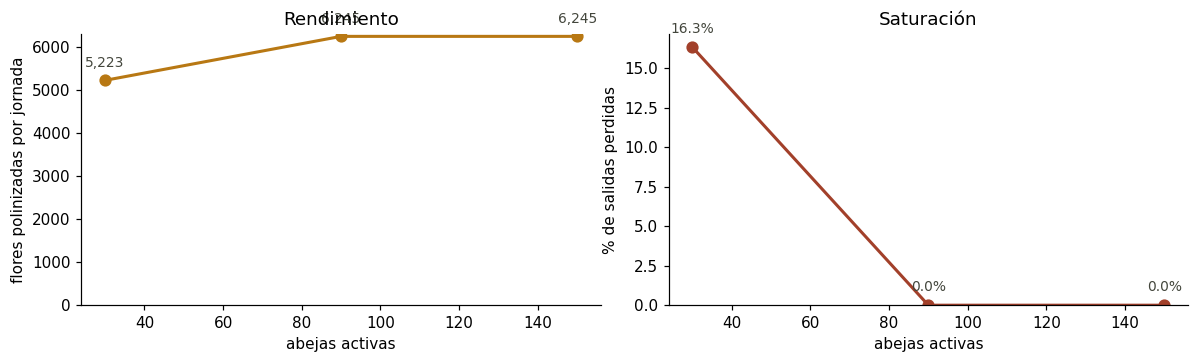

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
x = g['Abejas'].values

ax[0].plot(x, g['Polinizadas'], 'o-', color=AMBAR, lw=2, ms=7)
for xi, yi in zip(x, g['Polinizadas']):
    ax[0].annotate(f'{yi:,.0f}', (xi, yi), textcoords='offset points',
                   xytext=(0,9), ha='center', fontsize=9, color=TINTA)
ax[0].set_xlabel('abejas activas'); ax[0].set_ylabel('flores polinizadas por jornada')
ax[0].set_title('Rendimiento'); ax[0].set_ylim(0, None)

ax[1].plot(x, g['% perdidas'], 'o-', color=ALERTA, lw=2, ms=7)
for xi, yi in zip(x, g['% perdidas']):
    ax[1].annotate(f'{yi:.1f}%', (xi, yi), textcoords='offset points',
                   xytext=(0,9), ha='center', fontsize=9, color=TINTA)
ax[1].set_xlabel('abejas activas'); ax[1].set_ylabel('% de salidas perdidas')
ax[1].set_title('Saturación'); ax[1].set_ylim(0, None)
plt.tight_layout(); plt.show()

## 3. El efecto de la disponibilidad floral

El nivel de disponibilidad no mueve un solo parámetro: fija a la vez la media de
flores visitadas, la escala del néctar por flor y, en dirección contraria, la
escala del tiempo de búsqueda.

In [6]:
sub = df[df.escenario.isin(['flowers_low','base','flowers_high'])]
g = sub.groupby('escenario')[['flores_visitadas','flores_polinizadas','nectar_entregado_ml',
                              'duracion_media_min','viajes_completos',
                              'nectar_por_minuto_planificado_ml']].mean()
g = g.reindex(['flowers_low','base','flowers_high'])
g.index = [ETIQUETA[e] for e in g.index]
g.columns = ['Visitadas','Polinizadas','Néctar (ml)','Duración (min)',
             'Viajes compl.','Néctar/min']
print(g.to_string(float_format=lambda v: f'{v:,.2f}'))

             Visitadas  Polinizadas  Néctar (ml)  Duración (min)  Viajes compl.  Néctar/min
FLORES-BAJA   4,802.24     3,120.74       167.50           15.71       1,164.18        0.01
BASE          9,610.90     6,244.54       592.39           14.58       1,166.47        0.03
FLORES-ALTA  16,822.19    10,933.24     1,322.41           14.71       1,166.04        0.08


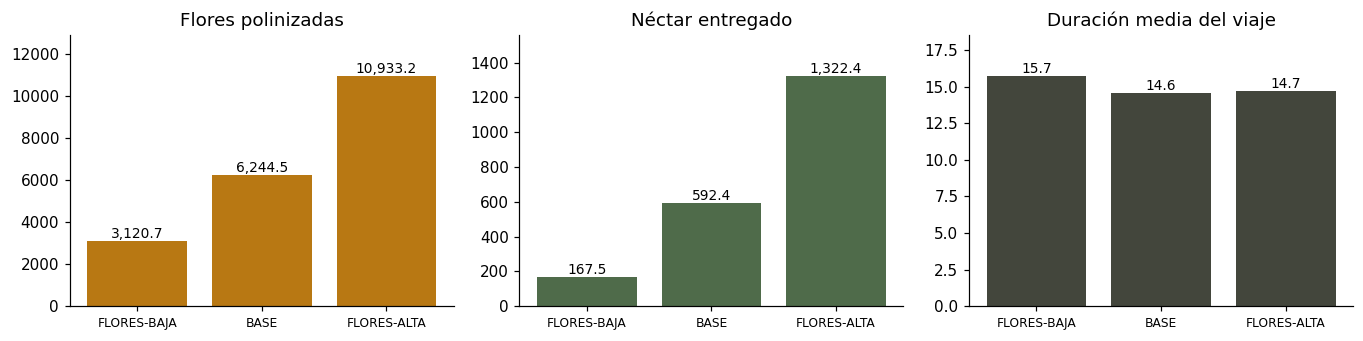

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.2))
et = list(g.index)
for a, col, titulo, color in [
        (ax[0], 'Polinizadas', 'Flores polinizadas', AMBAR),
        (ax[1], 'Néctar (ml)', 'Néctar entregado', SALVIA),
        (ax[2], 'Duración (min)', 'Duración media del viaje', TINTA)]:
    a.bar(et, g[col], color=color)
    a.set_title(titulo); a.tick_params(axis='x', labelsize=8)
    for i, v in enumerate(g[col]):
        a.text(i, v, f'{v:,.1f}', ha='center', va='bottom', fontsize=9)
    a.set_ylim(0, g[col].max()*1.18)
plt.tight_layout(); plt.show()

## 4. El efecto de la distancia

La distancia alimenta dos cosas independientes: el tiempo de vuelo, que consume
jornada, y la probabilidad de retorno.

In [8]:
sub = df[df.escenario.isin(['distance_near','base','distance_far'])]
g = sub.groupby('escenario')[['distancia_media_ida_km','duracion_media_min','viajes_completos',
                              'tasa_retorno','no_retorno_horizonte',
                              'no_retorno_distancia_en_jornada','flores_polinizadas',
                              'flores_polinizadas_por_km_planificado']].mean()
g = g.reindex(['distance_near','base','distance_far'])
g.index = [ETIQUETA[e] for e in g.index]
g.columns = ['D media (km)','Duración (min)','Viajes compl.','Retorno',
             'No ret. horizonte','No ret. distancia','Polinizadas','Polin./km']
print(g.to_string(float_format=lambda v: f'{v:,.3f}'))

            D media (km)  Duración (min)  Viajes compl.  Retorno  No ret. horizonte  No ret. distancia  Polinizadas  Polin./km
DIST-CERCA         0.709          10.819      1,179.336    0.982             21.754              0.126    6,244.536      3.665
BASE               1.330          14.581      1,166.470    0.971             29.284              5.462    6,244.536      1.955
DIST-LEJOS         2.665          22.670        392.252    0.812              0.576             89.408    2,505.680      0.975


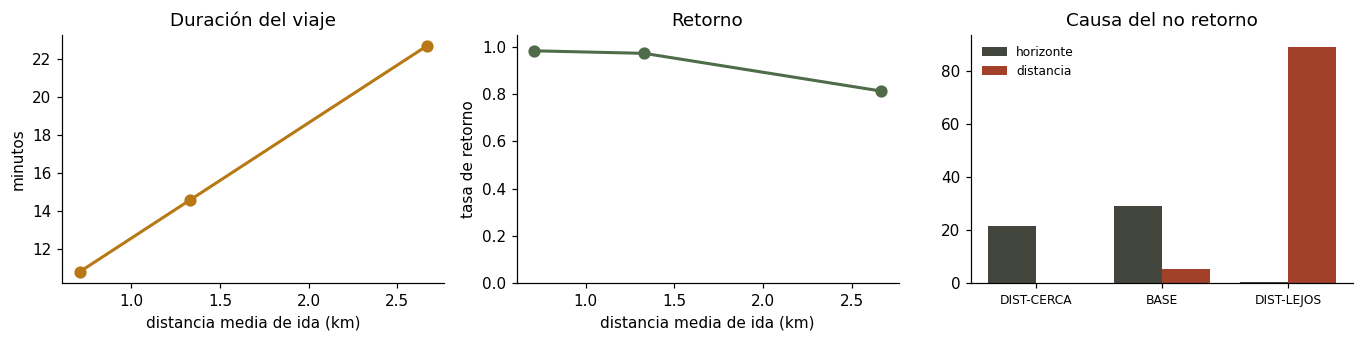

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.2))
d = g['D media (km)'].values

ax[0].plot(d, g['Duración (min)'], 'o-', color=AMBAR, lw=2, ms=7)
ax[0].set_xlabel('distancia media de ida (km)'); ax[0].set_ylabel('minutos')
ax[0].set_title('Duración del viaje')

ax[1].plot(d, g['Retorno'], 'o-', color=SALVIA, lw=2, ms=7)
ax[1].set_xlabel('distancia media de ida (km)'); ax[1].set_ylabel('tasa de retorno')
ax[1].set_title('Retorno'); ax[1].set_ylim(0, 1.05)

anchura = 0.38; idx = np.arange(len(g))
ax[2].bar(idx-anchura/2, g['No ret. horizonte'], anchura, color=TINTA, label='horizonte')
ax[2].bar(idx+anchura/2, g['No ret. distancia'], anchura, color=ALERTA, label='distancia')
ax[2].set_xticks(idx); ax[2].set_xticklabels(g.index, fontsize=8)
ax[2].set_title('Causa del no retorno'); ax[2].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

Separar las dos causas del no retorno importa para la interpretación. La
condición de horizonte proviene de la estructura del modelo y es indiscutible:
un viaje que no cabe en lo que resta de la jornada no puede completarse. La
condición de distancia, en cambio, depende de una función logística cuyos
parámetros son supuestos declarados (decisión D-11). Cuando la causa dominante
es el horizonte, la conclusión descansa sobre la parte sólida del modelo.

## 4 bis. El efecto de la intensidad de salidas

La intensidad `lambda` fija cuántas salidas pide el entorno por jornada. Si la
colonia tiene capacidad de sobra, el rendimiento debería escalar de forma
proporcional; cuando la demanda supera la capacidad, debería aparecer una
meseta.

In [10]:
lam = {'lambda_low':1.0,'base':2.0,'lambda_high':4.0}
sub = df[df.escenario.isin(lam)]
g = sub.groupby('escenario')[['salidas_totales','salidas_atendidas','salidas_perdidas',
                              'tasa_salidas_perdidas','viajes_completos',
                              'flores_polinizadas']].mean().reindex(list(lam))
g.insert(0, 'lambda', [lam[e] for e in g.index])
g.index = [ETIQUETA[e] for e in g.index]
g.columns = ['lambda','Salidas','Atendidas','Perdidas','% perdidas','Viajes compl.','Polinizadas']
g['% perdidas'] = g['% perdidas']*100
print(g.to_string(float_format=lambda v: f'{v:,.2f}'))

base_pol = g.loc['BASE','Polinizadas']
print('\nproporcionalidad respecto de BASE:')
for i, r in g.iterrows():
    print(f'  {i:14} lambda x{r["lambda"]/2:.1f}   polinizadas x{r["Polinizadas"]/base_pol:.3f}')

             lambda  Salidas  Atendidas  Perdidas  % perdidas  Viajes compl.  Polinizadas
LAMBDA-BAJA    1.00   602.20     602.20      0.00        0.00         584.98     3,128.14
BASE           2.00 1,201.22   1,201.22      0.00        0.00       1,166.47     6,244.54
LAMBDA-ALTA    4.00 2,401.87   2,400.33      1.54        0.06       2,331.14    12,479.39

proporcionalidad respecto de BASE:
  LAMBDA-BAJA    lambda x0.5   polinizadas x0.501
  BASE           lambda x1.0   polinizadas x1.000
  LAMBDA-ALTA    lambda x2.0   polinizadas x1.998


In [11]:
# capacidad teorica de la colonia: cuantos viajes caben en la jornada
import sys; sys.path.insert(0, '../src')
from bee_sim.config import cargar
cfg = cargar('../config/base.yaml')
n_ab = cfg['colony']['active_bees']; T = cfg['simulation']['day_minutes']
dur = df[df.escenario=='base'].duracion_media_min.mean()
capacidad = n_ab * T / dur
lam_critico = capacidad / T
print(f'forrajeras                     {n_ab}')
print(f'duración media del viaje       {dur:.2f} min')
print(f'capacidad de la colonia        {capacidad:,.0f} viajes por jornada')
print(f'lambda a la que se satura      {lam_critico:.2f} salidas/min')
print(f'lambda máximo ensayado         4.00 salidas/min  ({100*4/lam_critico:.0f}% de la capacidad)')

forrajeras                     90
duración media del viaje       14.58 min
capacidad de la colonia        3,703 viajes por jornada
lambda a la que se satura      6.17 salidas/min
lambda máximo ensayado         4.00 salidas/min  (65% de la capacidad)


**Lectura.** La polinización escala de forma exactamente proporcional a
`lambda`: al duplicar la intensidad se duplica el resultado, y al cuadruplicarla
se cuadruplica. En todo el rango ensayado el sistema está **limitado por la
demanda**, no por la capacidad de la colonia.

El cálculo de capacidad explica por qué: con 90 forrajeras y viajes de unos 14.6
minutos, la colonia soporta del orden de 3,700 viajes por jornada, y el `lambda`
más alto ensayado solo pide 2,400. La saturación de la Figura 3 aparece por el
otro lado, reduciendo forrajeras, no aumentando la demanda.

Los dos regímenes quedan así documentados: ABEJAS-BAJA muestra el limitado por
capacidad y el barrido de `lambda` muestra el limitado por demanda.

## 4 ter. El efecto de la probabilidad de polinización

`p_pol` es el único factor que actúa sobre la conversión de visitas en
polinizaciones, sin tocar cuántas flores se visitan.

In [12]:
pp = {'pollination_low':0.40,'base':0.65,'pollination_high':0.85}
sub = df[df.escenario.isin(pp)]
g = sub.groupby('escenario')[['flores_visitadas','flores_polinizadas',
                              'tasa_polinizacion','nectar_entregado_ml']].mean().reindex(list(pp))
g.insert(0, 'p configurado', [pp[e] for e in g.index])
g['error %'] = 100*(g.tasa_polinizacion - g['p configurado']).abs()/g['p configurado']
g.index = [ETIQUETA[e] for e in g.index]
g.columns = ['p configurado','Visitadas','Polinizadas','Tasa observada','Néctar (ml)','Error %']
print(g.to_string(float_format=lambda v: f'{v:,.4f}'))

            p configurado  Visitadas  Polinizadas  Tasa observada  Néctar (ml)  Error %
POLIN-BAJA         0.4000 9,610.9040   3,842.4260          0.3998     592.3914   0.0523
BASE               0.6500 9,610.9040   6,244.5360          0.6497     592.3914   0.0408
POLIN-ALTA         0.8500 9,610.9040   8,165.8840          0.8497     592.3914   0.0408


**Lectura.** La tasa observada reproduce el parámetro configurado con un
error menor al 0.06% en los tres niveles. Y las flores visitadas y el néctar se
mantienen prácticamente iguales entre los tres escenarios, lo que confirma que
`p_pol` está bien aislado: cambia únicamente la conversión, sin contaminar el
resto del modelo.

## 5. El escenario combinado

Menos flores y mayor distancia a la vez, la condición de mayor presión sobre el
forrajeo. Interesa saber si el efecto conjunto es la suma de los efectos
individuales o si hay interacción.

In [13]:
base_pol = df[df.escenario=='base'].flores_polinizadas.mean()
fl = df[df.escenario=='flowers_low'].flores_polinizadas.mean()
di = df[df.escenario=='distance_far'].flores_polinizadas.mean()
co_ = df[df.escenario=='combined'].flores_polinizadas.mean()

ef_flores = fl - base_pol
ef_dist   = di - base_pol
esperado  = base_pol + ef_flores + ef_dist

print(f'BASE                                {base_pol:9,.1f}')
print(f'FLORES-BAJA                         {fl:9,.1f}   efecto {ef_flores:+9,.1f}')
print(f'DIST-LEJOS                          {di:9,.1f}   efecto {ef_dist:+9,.1f}')
print(f'suma de los dos efectos (esperado)  {esperado:9,.1f}')
print(f'COMBINADO observado                 {co_:9,.1f}')
print(f'\ninteracción = observado - esperado  {co_-esperado:+9,.1f}')
print('positiva: los efectos se atenúan entre sí' if co_ > esperado
      else 'negativa: los efectos se refuerzan entre sí')

BASE                                  6,244.5
FLORES-BAJA                           3,120.7   efecto  -3,123.8
DIST-LEJOS                            2,505.7   efecto  -3,738.9
suma de los dos efectos (esperado)     -618.1
COMBINADO observado                   1,247.6

interacción = observado - esperado   +1,865.7
positiva: los efectos se atenúan entre sí


## 6. ¿Alcanzan 500 réplicas?

El informe planteaba mil réplicas como mínimo, ajustable tras medir el costo. La
pregunta correcta no es cuántas réplicas sino qué tan angosto queda el intervalo
de confianza de la media.

In [14]:
print(f"{'Escenario':14} {'media':>10} {'sd':>9} {'error est.':>11} {'IC 95%':>22} {'ancho':>8}")
print('-'*80)
for esc in ORDEN:
    v = df[df.escenario==esc].flores_polinizadas
    n = len(v); m = v.mean(); s = v.std(ddof=1); ee = s/math.sqrt(n)
    lo, hi = m-1.96*ee, m+1.96*ee
    print(f'{ETIQUETA[esc]:14} {m:10,.1f} {s:9,.1f} {ee:11,.2f} '
          f'[{lo:9,.1f}, {hi:9,.1f}] {200*1.96*ee/m:7.2f}%')

Escenario           media        sd  error est.                 IC 95%    ancho
--------------------------------------------------------------------------------
ABEJAS-BAJA       5,222.8     214.1        9.58 [  5,204.0,   5,241.6]    0.72%
BASE              6,244.5     205.2        9.18 [  6,226.5,   6,262.5]    0.58%
ABEJAS-ALTA       6,244.5     205.2        9.18 [  6,226.5,   6,262.5]    0.58%
FLORES-BAJA       3,120.7     107.6        4.81 [  3,111.3,   3,130.2]    0.60%
FLORES-ALTA      10,933.2     330.4       14.78 [ 10,904.3,  10,962.2]    0.53%
DIST-CERCA        6,244.5     205.2        9.18 [  6,226.5,   6,262.5]    0.58%
DIST-LEJOS        2,505.7     241.5       10.80 [  2,484.5,   2,526.8]    1.69%
LAMBDA-BAJA       3,128.1     146.6        6.55 [  3,115.3,   3,141.0]    0.82%
LAMBDA-ALTA      12,479.4     305.9       13.68 [ 12,452.6,  12,506.2]    0.43%
POLIN-BAJA        3,842.4     133.7        5.98 [  3,830.7,   3,854.1]    0.61%
POLIN-ALTA        8,165.9     261.2    

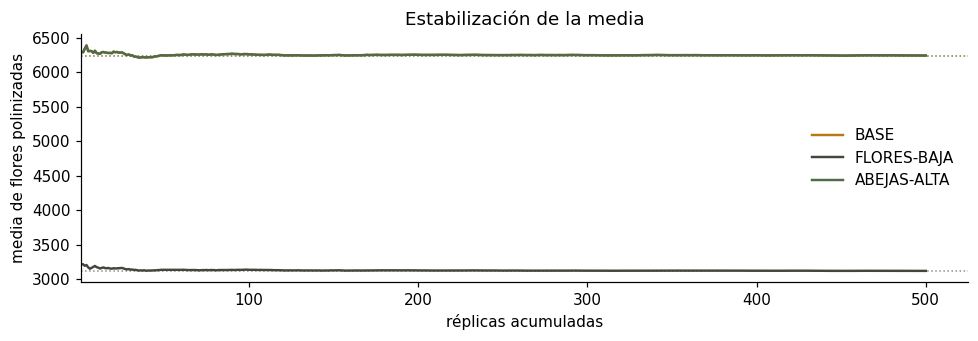

In [15]:
# como se estabiliza la media conforme se acumulan replicas
fig, ax = plt.subplots(figsize=(9, 3.2))
for esc, color in [('base', AMBAR), ('flowers_low', TINTA), ('bees_high', SALVIA)]:
    v = df[df.escenario==esc].flores_polinizadas.values
    corrida = np.cumsum(v)/np.arange(1, len(v)+1)
    ax.plot(range(1, len(v)+1), corrida, color=color, lw=1.6, label=ETIQUETA[esc])
    ax.axhline(v.mean(), color=color, ls=':', lw=1, alpha=.6)
ax.set_xlabel('réplicas acumuladas'); ax.set_ylabel('media de flores polinizadas')
ax.set_title('Estabilización de la media'); ax.legend(frameon=False)
ax.set_xlim(1, None)
plt.tight_layout(); plt.show()

## Conclusiones cuantitativas

Espacio para redactar, con los números de arriba a la vista. Las conclusiones
del informe deben citar el escenario que sustenta cada una y distinguir entre
resultados que salen de la estructura matemática del modelo y resultados
sensibles a los parámetros declarados como supuestos en `docs/assumptions.md`.

---

*Documento generado por ejecución directa sobre los resultados guardados en
`results/runs/`. Especificación del modelo en `docs/model.md`; decisiones de
diseño en `docs/decisions.md`.*